In [ ]:
import pandas as pd
df = pd.read_csv('/content/open_iit_train_dataset_final.csv')

In [ ]:
df.columns


Index(['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'TAIL_NUM',
       'DEST', 'DEP_DELAY', 'CRS_ELAPSED_TIME', 'DISTANCE', 'CRS_DEP_M',
       'DEP_TIME_M', 'CRS_ARR_M', 'Temperature', 'Dew Point', 'Humidity',
       'Wind', 'Wind Speed', 'Wind Gust', 'Pressure', 'Condition', 'sch_dep',
       'sch_arr', 'TAXI_OUT', 'air_traffic', 'footfall_passengers',
       'fuel_availability', 'late_arrival_prev_airport',
       'ground_staff_available', 'perc_passengers_late', 'air_staff_available',
       'connecting_flights'],
      dtype='object')

In [ ]:
####### DO NOT TOUCH THIS BIT OF CODE PLEASE ########
df['ground_staff_available'] = df['ground_staff_available']*800
df['air_staff_available'] = df['air_staff_available']*300
df['perc_passengers_late'] = df['perc_passengers_late']/10
df['connecting_flights'] = df['connecting_flights']* 155
df['footfall_passengers'] = df['footfall_passengers']*600
df['air_traffic'] = df['air_traffic']*500


In [ ]:
# I am assuming the year is 2023
df['YEAR'] = 2019
df.rename(columns={'DAY_OF_MONTH': 'day'}, inplace=True)
df['Date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'day']])

In [ ]:
df.head()

,MONTH,day,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,air_traffic,footfall_passengers,fuel_availability,late_arrival_prev_airport,ground_staff_available,perc_passengers_late,air_staff_available,connecting_flights,YEAR,Date
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,76000,3989400,Yes,163,76000,6.312,4800,775,2019,2019-11-01
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,242500,5394000,Yes,78,68800,6.586,1200,930,2019,2019-11-01
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,199000,3377400,No,157,49600,6.975,3600,2945,2019,2019-11-01
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,160000,5039400,Yes,47,4800,7.614,2400,2635,2019,2019-11-01
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,78000,5208000,No,77,50400,8.331,900,1550,2019,2019-11-01


In [ ]:
#Validating data types for all features
# Check for expected ranges in key columns
print(df[['MONTH', 'day', 'DAY_OF_WEEK']].describe()) # Changed 'DAY_OF_MONTH' to 'day'
print(df[['Temperature', 'Humidity', 'Wind Speed']].describe())
print(df['fuel_availability'].unique())

              MONTH           day   DAY_OF_WEEK
count  28820.000000  28820.000000  28820.000000
mean       7.894240     16.021096      4.008952
std        4.991723      8.750179      1.985230
min        1.000000      1.000000      1.000000
25%        1.000000      8.000000      2.000000
50%       11.000000     16.000000      4.000000
75%       12.000000     24.000000      6.000000
max       12.000000     31.000000      7.000000
        Temperature      Humidity    Wind Speed
count  28820.000000  28820.000000  28820.000000
mean      41.489833     57.732616     12.367627
std        8.043533     23.468676      6.259298
min       17.000000      0.000000      0.000000
25%       36.000000     46.000000      8.000000
50%       42.000000     59.000000     12.000000
75%       47.000000     74.000000     16.000000
max       68.000000     97.000000     36.000000
['Yes' 'No']


In [ ]:
#### USE THIS DATASET FOR SUBMISSION
df.to_csv('training_dataset.csv',index=False)

In [ ]:
#Checking for missing values
# Display missing values for each column
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Wind    2
dtype: int64


In [ ]:
# Display unique values in categorical columns
print(df['OP_UNIQUE_CARRIER'].unique())
print(df['DEST'].unique())
print(df['Condition'].unique())
print(df['Wind'].unique())


['B6' 'DL' 'AA' 'AS' 'MQ' '9E' 'YX' 'HA' 'OO']
['CHS' 'LAX' 'FLL' 'MCO' 'ATL' 'ORD' 'BUF' 'LGB' 'LAS' 'DCA' 'PHX' 'SFO'
 'SJU' 'SLC' 'BOS' 'SAV' 'SYR' 'MSP' 'SEA' 'MIA' 'PDX' 'TPA' 'BTV' 'IAH'
 'DEN' 'RSW' 'ORF' 'JAX' 'MSY' 'CLT' 'BNA' 'RDU' 'SAN' 'SJC' 'ROC' 'DFW'
 'IAD' 'AUS' 'DTW' 'PWM' 'SRQ' 'CMH' 'HNL' 'PBI' 'BWI' 'CLE' 'BUR' 'PIT'
 'RIC' 'IND' 'CVG' 'SMF' 'ONT' 'SAT' 'PSP' 'OAK' 'ABQ' 'PSE' 'ORH' 'BQN'
 'STT' 'RNO' 'PHL' 'EGE' 'JAC']
['Fair / Windy' 'Fair' 'Light Rain / Windy' 'Partly Cloudy'
 'Mostly Cloudy' 'Cloudy' 'Light Rain' 'Mostly Cloudy / Windy'
 'Partly Cloudy / Windy' 'Light Snow / Windy' 'Cloudy / Windy'
 'Light Drizzle' 'Rain' 'Heavy Rain' 'Fog' 'Wintry Mix'
 'Light Freezing Rain' 'Light Snow' 'Wintry Mix / Windy' 'Fog / Windy'
 'Light Drizzle / Windy' 'Rain / Windy' 'Drizzle and Fog' 'Snow'
 'Heavy Rain / Windy']
['W' 'WNW' 'NW' 'NNW' 'S' 'ENE' 'NE' 'NNE' 'E' 'SE' 'CALM' 'SW' 'VAR'
 'SSE' 'SSW' 'WSW' 'N' 'ESE' nan]


In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


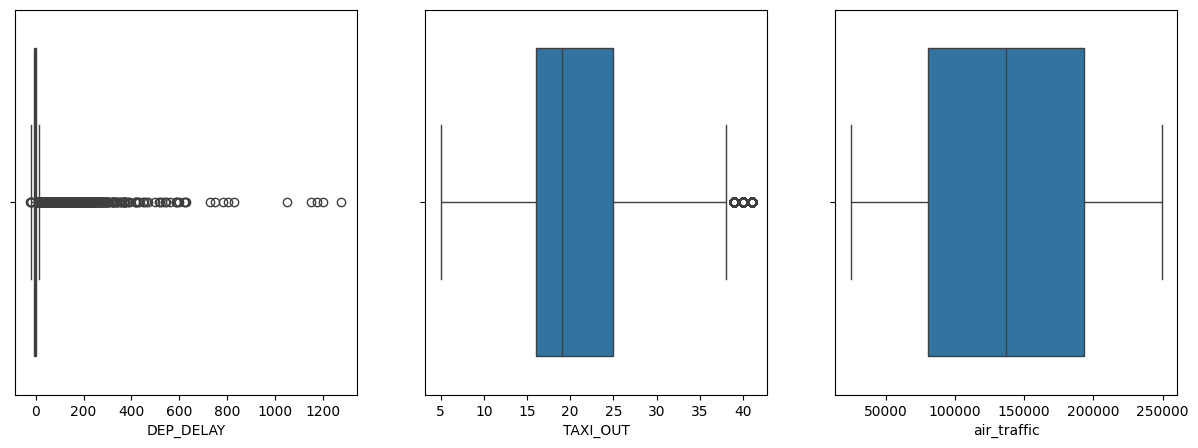

In [ ]:
#outlier detection

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outliers in continuous data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, x='DEP_DELAY', ax=axes[0])
sns.boxplot(data=df, x='TAXI_OUT', ax=axes[1])
sns.boxplot(data=df, x='air_traffic', ax=axes[2])
plt.show()




In [ ]:
import numpy as np

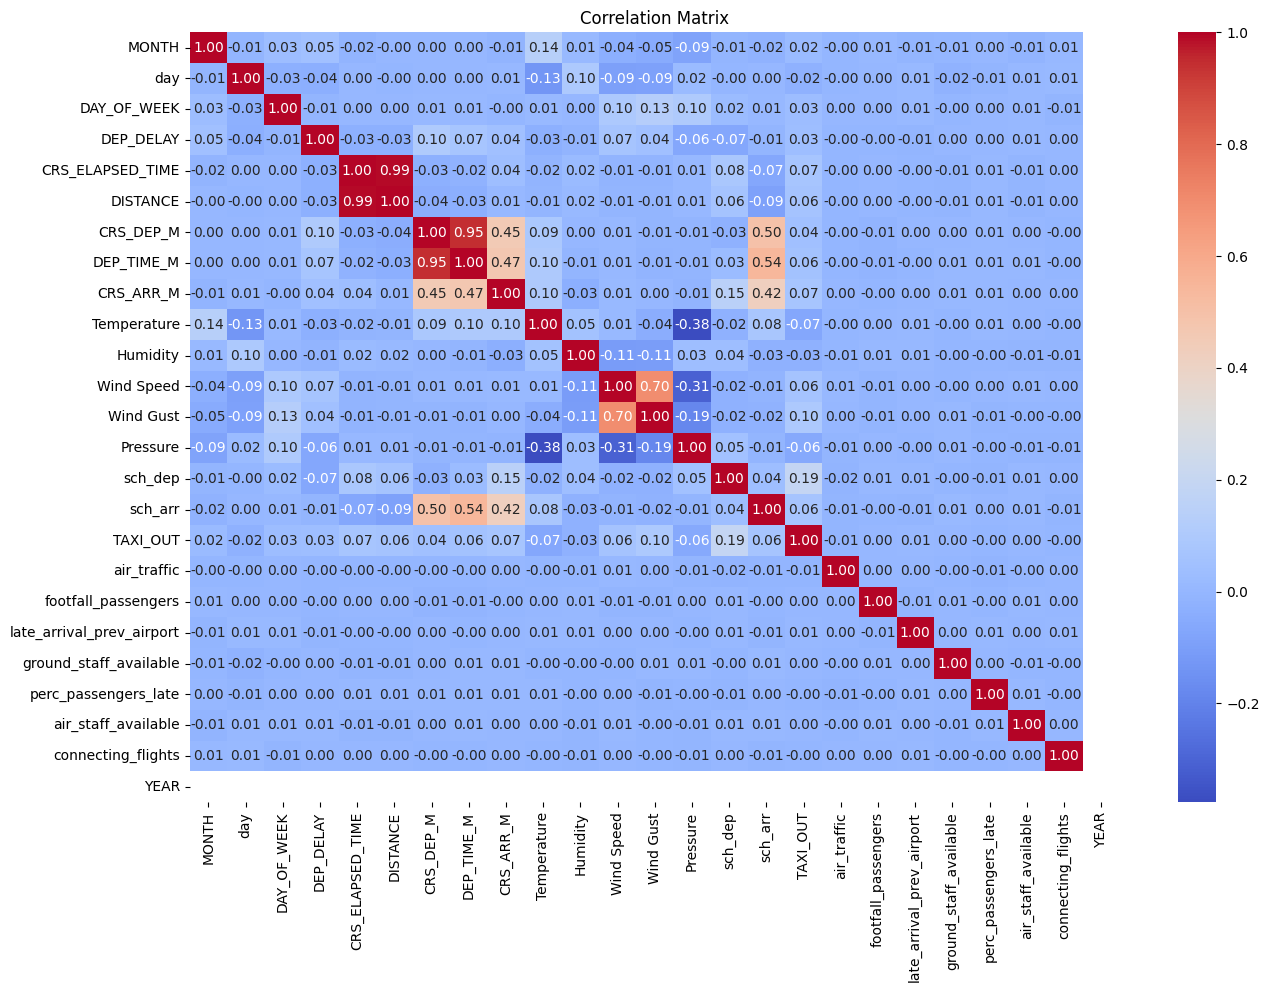

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Plot a correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


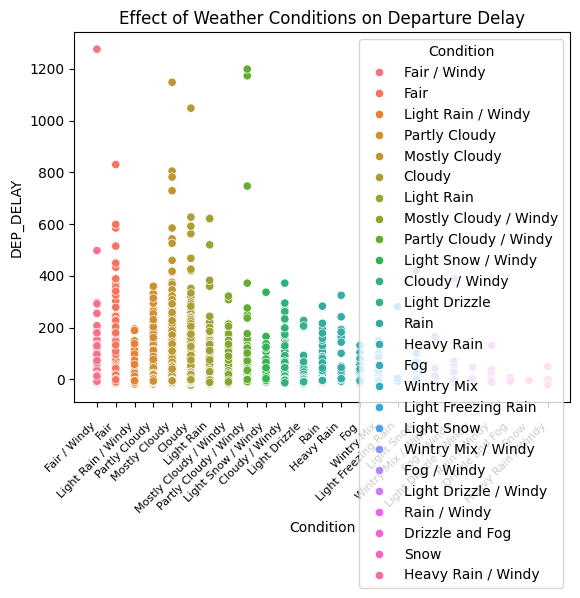

<Figure size 1000x600 with 0 Axes>

In [ ]:


# Assuming 'time' is your numerical feature and 'category' is your categorical feature
sns.scatterplot(x="Condition", y="DEP_DELAY", data=df, hue="Condition", palette="husl")

# Customize the plot
plt.title("Effect of Weather Conditions on Departure Delay", fontsize=12)  # Reduce title font size
plt.xlabel("Condition", fontsize=10)  # Reduce x-axis label font size
plt.ylabel("DEP_DELAY", fontsize=10)  # Reduce y-axis label font size

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45, ha='right', fontsize=8)

# Shift the x-axis ticks slightly to avoid overlapping with the graph
plt.gca().tick_params(axis='x', pad=10)
# Increase figure size

plt.figure(figsize=(10, 6))


# Show the plot
plt.show()



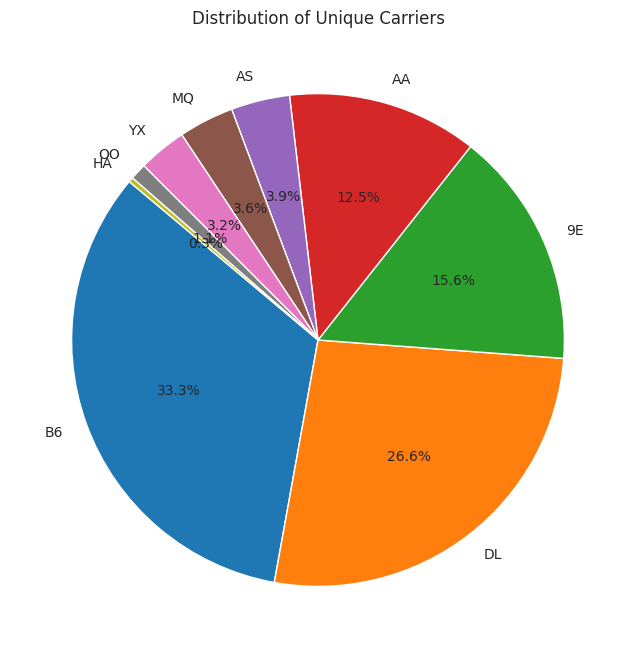

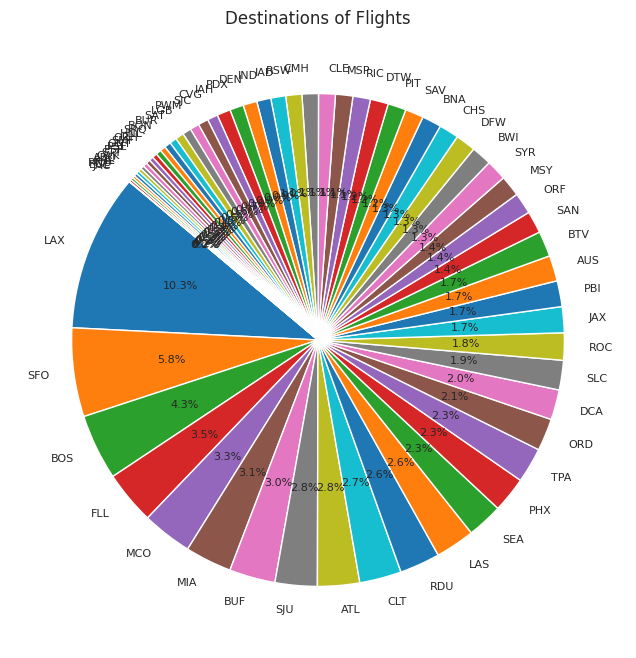

In [ ]:
#PIE CHARTS
category_counts = df['OP_UNIQUE_CARRIER'].value_counts()

# Create the pie chart using Seaborn
plt.figure(figsize=(8, 8))
sns.set_style("darkgrid")
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Unique Carriers")
plt.show()

category_counts = df['DEST'].value_counts()

# Create the pie chart using Seaborn
plt.figure(figsize=(8, 8))
sns.set_style("darkgrid")
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 8})
plt.title("Destinations of Flights")
plt.show()

<ipython-input-16-c9d455ef2476>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=column_name, data=df, palette='Set2' , inner='quartile')


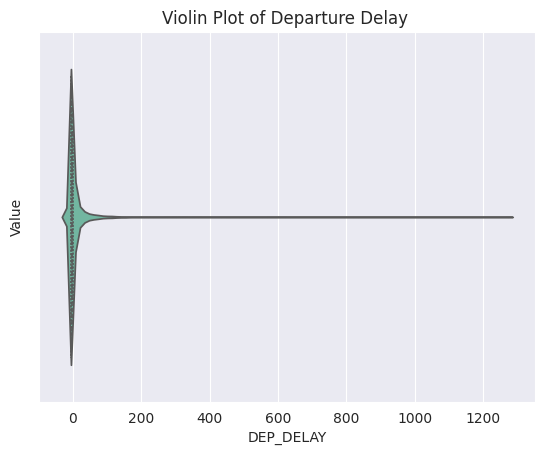

In [ ]:
#VIOLIN PLOTS
# Select the column you want to visualize
column_name = 'DEP_DELAY'

# Create the violin plot using Seaborn for more customization
sns.violinplot(x=column_name, data=df, palette='Set2' , inner='quartile')

# Customize the plot
plt.title('Violin Plot of Departure Delay ')
plt.xlabel(column_name)
plt.ylabel('Value')

plt.show()

<ipython-input-17-347f88f7245f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_OF_WEEK', y='footfall_passengers', data=df, palette='viridis')


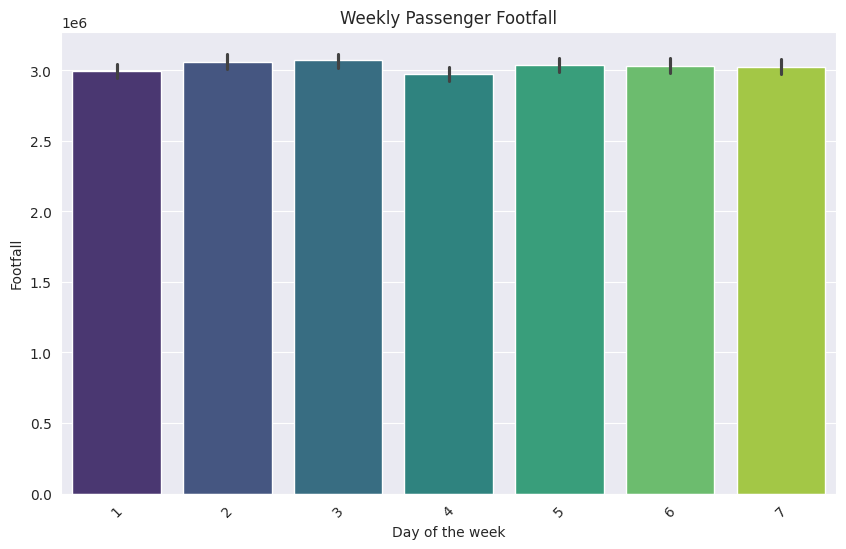

In [ ]:
# Assuming 'month' and 'footfall' are the relevant columns
plt.figure(figsize=(10, 6))
sns.barplot(x='DAY_OF_WEEK', y='footfall_passengers', data=df, palette='viridis')
plt.title('Weekly Passenger Footfall')
plt.xlabel('Day of the week')
plt.ylabel('Footfall')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

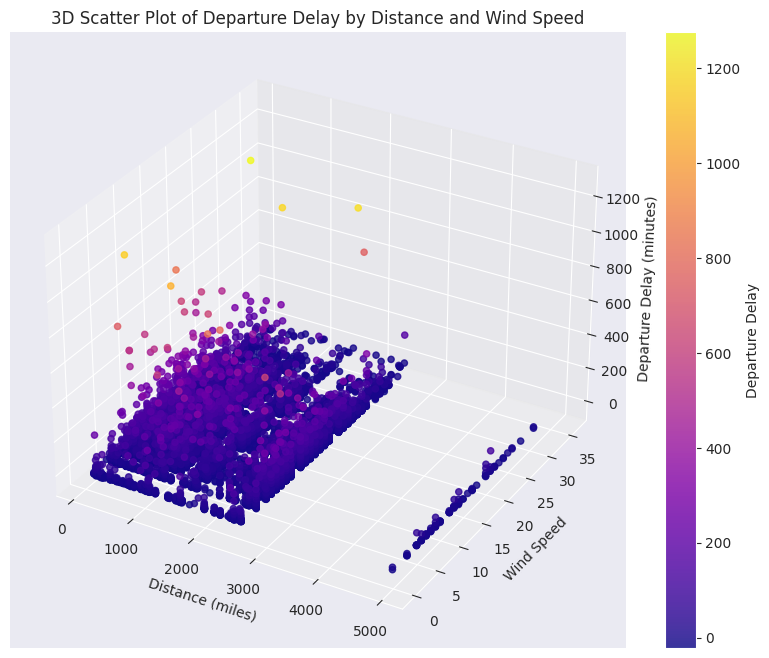

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define x, y, z from your DataFrame (assuming df is defined)
x = df['DISTANCE']          # X-axis: Flight distance
y = df['Wind Speed']           # Y-axis: Air time
z = df['DEP_DELAY']  # Z-axis: Delay due to carrier

sc = ax.scatter(x, y, z, c=z, cmap='plasma', marker='o', alpha=0.8)

ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Wind Speed')
ax.set_zlabel('Departure Delay (minutes)')
plt.colorbar(sc, ax=ax, label='Departure Delay')
plt.title('3D Scatter Plot of Departure Delay by Distance and Wind Speed')
plt.show()


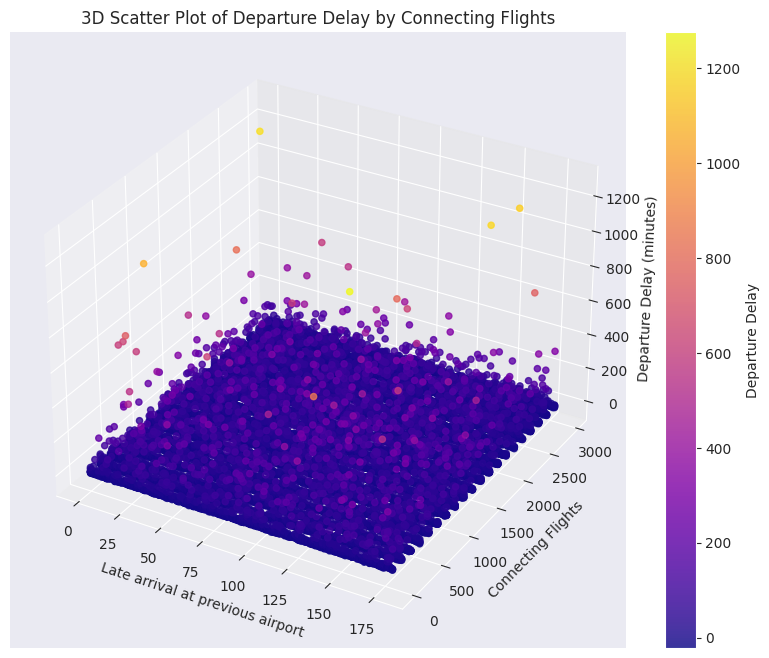

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define x, y, z from your DataFrame (assuming df is defined)
x = df['late_arrival_prev_airport']          # X-axis: Flight distance
y = df['connecting_flights']           # Y-axis: Air time
z = df['DEP_DELAY']  # Z-axis: Delay due to carrier

sc = ax.scatter(x, y, z, c=z, cmap='plasma', marker='o', alpha=0.8)

ax.set_xlabel('Late arrival at previous airport')
ax.set_ylabel('Connecting Flights')
ax.set_zlabel('Departure Delay (minutes)')
plt.colorbar(sc, ax=ax, label='Departure Delay')
plt.title('3D Scatter Plot of Departure Delay by Connecting Flights')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has be

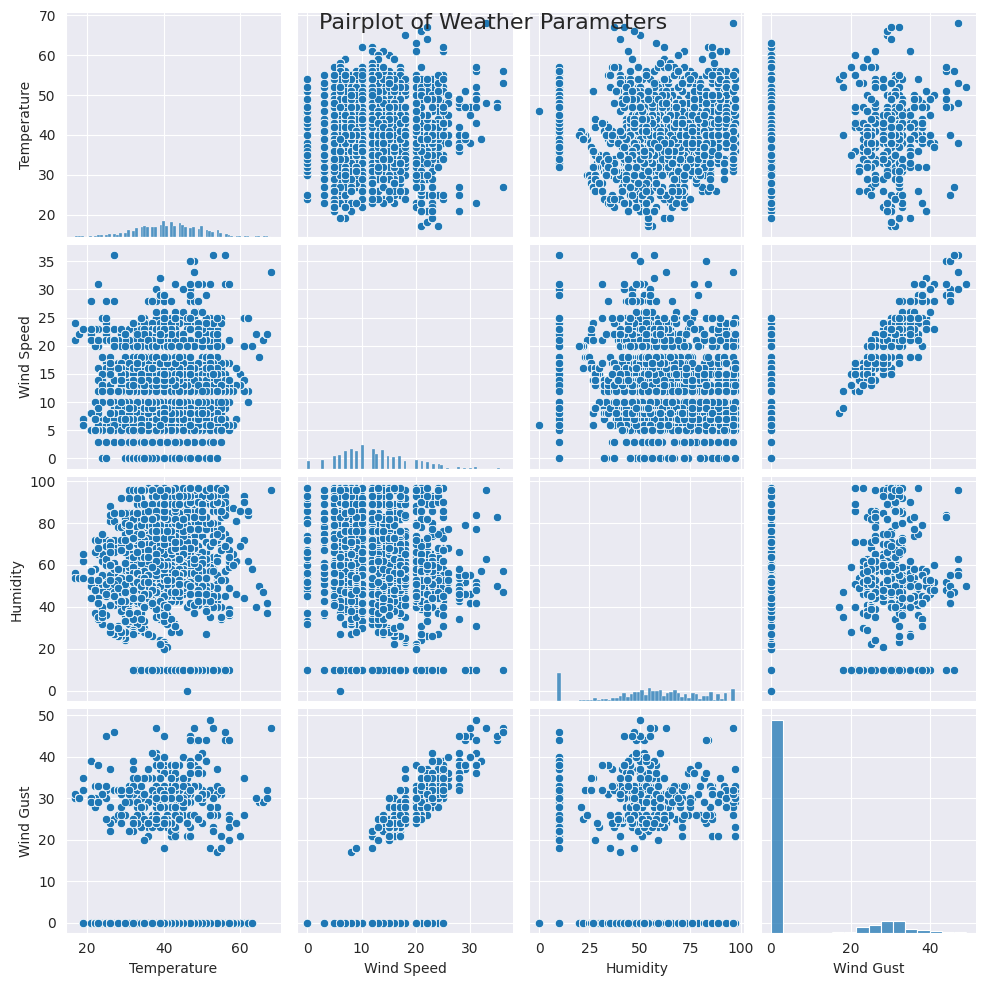

In [ ]:
  import pandas as pd
  import seaborn as sns
  import matplotlib.pyplot as plt


  # Select the desired numerical features
  selected_features = ['Temperature', 'Wind Speed', 'Humidity', 'Wind Gust']  # Replace with your feature names

  # Create the pairplot with a warm color palette and title
  sns.pairplot(df[selected_features], palette='flare')
  plt.suptitle('Pairplot of Weather Parameters', fontsize=16)
  plt.show()

FEATURE SCALING

In [ ]:
#### label encoding for some features
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['career_encode'] = label_encoder.fit_transform(df['OP_UNIQUE_CARRIER'])
df['Wind'] = label_encoder.fit_transform(df['Wind'])
df['Condition'] = label_encoder.fit_transform(df['Condition'])

In [ ]:
df['Dew Point'] =df['Dew Point'].astype(float)

In [ ]:
### outlier detection by IQR
columns = ['DISTANCE', 'Temperature', 'Humidity', 'Wind Speed', 'Dew Point',
           'Wind Gust', 'Pressure', 'air_traffic', 'footfall_passengers', 'late_arrival_prev_airport',
           'perc_passengers_late', 'connecting_flights', 'air_staff_available']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

### capping to remove the outliers
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

In [ ]:

from scipy.stats import skew, boxcox
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
import numpy as np

In [ ]:
#### finding out the skewness of different columns
column_skewness = {}
for col in columns:
    column_skewness[col] = skew(df[col].dropna())

In [ ]:
for col, skewness in column_skewness.items():
    if abs(skewness) < 0.5:
        # Z-score normalization for approximately normal data
        scaler = StandardScaler()
        df[col] = scaler.fit_transform(df[[col]])
    elif 0.5 <= abs(skewness) < 1:
        # Yeo-Johnson Transformation for mildly skewed data
        yeo_johnson = PowerTransformer(method='yeo-johnson')
        df[col] = yeo_johnson.fit_transform(df[[col]])
    else:
        # Log Transformation or Quantile Transformation for highly skewed data
        if (df[col] > 0).all():
            df[col] = np.log(df[col] + 1e-6)
        else:
            quantile_transformer = QuantileTransformer(output_distribution='normal')
            df[col] = quantile_transformer.fit_transform(df[[col]])

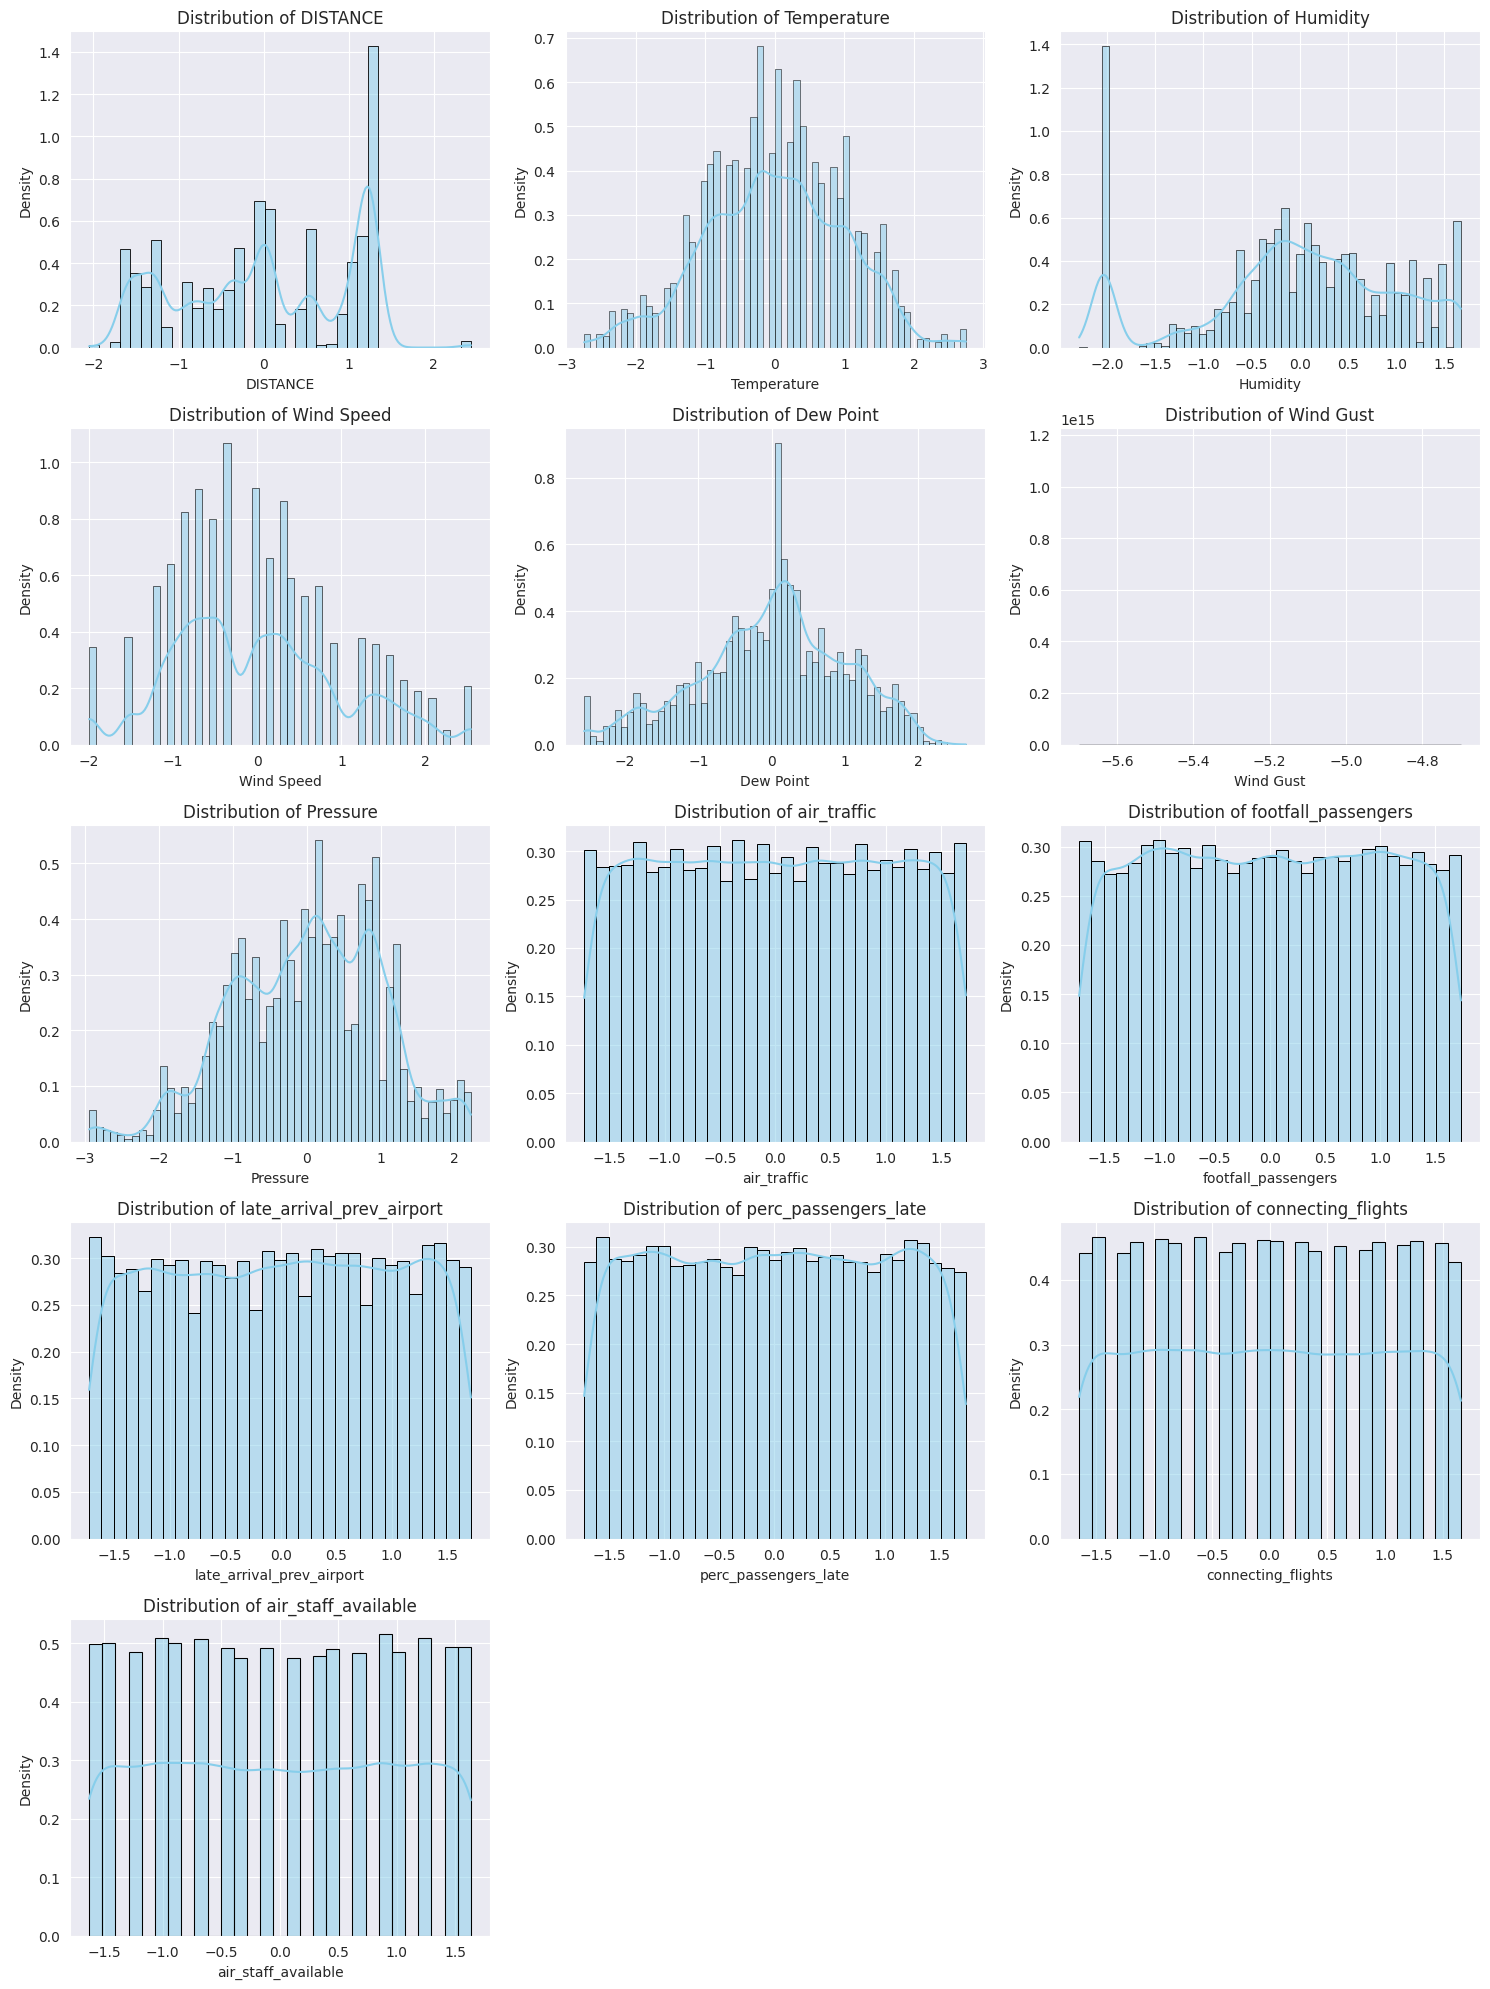

In [ ]:
##### Plots after scaling
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 20))
for i, col in enumerate(columns, 1):
    plt.subplot(5, 3, i)
    sns.histplot(df[col], kde=True, stat="density", color="skyblue", edgecolor="black")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

MODEL

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.2 MB/s eta 0:00:00


In [ ]:
#### label encoding for some features
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['career_encode'] = label_encoder.fit_transform(df['OP_UNIQUE_CARRIER'])
df['Wind'] = label_encoder.fit_transform(df['Wind'])
df['Condition'] = label_encoder.fit_transform(df['Condition'])

df['Dew Point'] =df['Dew Point'].astype(float)      ### outlier detection by IQR
columns = ['DISTANCE', 'Temperature', 'Humidity', 'Wind Speed', 'Dew Point',
           'Wind Gust', 'Pressure', 'air_traffic', 'footfall_passengers', 'late_arrival_prev_airport',
           'perc_passengers_late', 'connecting_flights', 'staff_available']


#### label encoding for some features
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
import numpy as np

label_encoder = LabelEncoder()
df['career_encode'] = label_encoder.fit_transform(df['OP_UNIQUE_CARRIER'])
df['Wind'] = label_encoder.fit_transform(df['Wind'])
df['Condition'] = label_encoder.fit_transform(df['Condition'])

df['Dew Point'] =df['Dew Point'].astype(float)      ### outlier detection by IQR
columns = ['DISTANCE', 'Temperature', 'Humidity', 'Wind Speed', 'Dew Point',
           'Wind Gust', 'Pressure', 'air_traffic', 'footfall_passengers', 'late_arrival_prev_airport',
           'perc_passengers_late', 'connecting_flights', 'ground_staff_available', 'air_staff_available']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

### capping to remove the outliers
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

#### finding out the skewness of different columns
column_skewness = {}
for col in columns:
    column_skewness[col] = skew(df[col].dropna())
for col, skewness in column_skewness.items():
    if abs(skewness) < 0.5:
        # Z-score normalization for approximately normal data
        scaler = StandardScaler()
        df[col] = scaler.fit_transform(df[[col]])
    elif 0.5 <= abs(skewness) < 1:
        # Yeo-Johnson Transformation for mildly skewed data
        yeo_johnson = PowerTransformer(method='yeo-johnson')
        df[col] = yeo_johnson.fit_transform(df[[col]])
    else:
        # Log Transformation or Quantile Transformation for highly skewed data
        if (df[col] > 0).all():
            df[col] = np.log(df[col] + 1e-6)
        else:
            quantile_transformer = QuantileTransformer(output_distribution='normal')
            df[col] = quantile_transformer.fit_transform(df[[col]])
column_skewness = {}
for col in columns:
    column_skewness[col] = skew(df[col].dropna())

for col, skewness in column_skewness.items():
    if abs(skewness) < 0.5:
        # Z-score normalization for approximately normal data
        scaler = StandardScaler()
        df[col] = scaler.fit_transform(df[[col]])
    elif 0.5 <= abs(skewness) < 1:
        # Yeo-Johnson Transformation for mildly skewed data
        yeo_johnson = PowerTransformer(method='yeo-johnson')
        df[col] = yeo_johnson.fit_transform(df[[col]])
    else:
        # Log Transformation or Quantile Transformation for highly skewed data
        if (df[col] > 0).all():
            df[col] = np.log(df[col] + 1e-6)
        else:
            quantile_transformer = QuantileTransformer(output_distribution='normal')
            df[col] = quantile_transformer.fit_transform(df[[col]])

<ipython-input-30-346581728056>:45: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  column_skewness[col] = skew(df[col].dropna())
<ipython-input-30-346581728056>:64: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  column_skewness[col] = skew(df[col].dropna())


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Load dataset
df = pd.read_csv('/content/openiit_test_dataset.csv')  # Replace with your dataset path

# Convert object columns to numerical using LabelEncoder
label_cols = ['OP_UNIQUE_CARRIER', 'TAIL_NUM', 'DEST', 'fuel_availability', 'Dew Point', 'Wind', 'Condition']
for col in label_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Handle datetime column if present
if 'Date' in df.columns:
    df['day'] = pd.to_datetime(df['Date']).dt.day
    df['month'] = pd.to_datetime(df['Date']).dt.month
    df['weekday'] = pd.to_datetime(df['Date']).dt.weekday
    df = df.drop('Date', axis=1)

# Ensure all features are numeric
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)  # Fill any remaining NaNs after conversion

# Define features and target variable
X = df.drop('DEP_DELAY', axis=1)
y = df['DEP_DELAY']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grids for RandomizedSearchCV
xgb_param_grid = {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7, 10], 'subsample': [0.6, 0.8, 1.0]}
lgb_param_grid = {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [-1, 5, 10, 15], 'num_leaves': [20, 31, 50, 100], 'min_child_samples': [5, 10, 20]}
cb_param_grid = {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'depth': [3, 5, 7, 10]}

# Model setup
xgb_model = xgb.XGBRegressor(random_state=42, enable_categorical=True)
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
cb_model = cb.CatBoostRegressor(random_seed=42, verbose=0)

# Perform RandomizedSearchCV for each model
xgb_random = RandomizedSearchCV(xgb_model, xgb_param_grid, n_iter=10, scoring='neg_mean_squared_error', cv=3, random_state=42, n_jobs=-1)
lgb_random = RandomizedSearchCV(lgb_model, lgb_param_grid, n_iter=10, scoring='neg_mean_squared_error', cv=3, random_state=42, n_jobs=-1)
cb_random = RandomizedSearchCV(cb_model, cb_param_grid, n_iter=10, scoring='neg_mean_squared_error', cv=3, random_state=42, n_jobs=-1)

# Fit each model
xgb_random.fit(X_train, y_train)
lgb_random.fit(X_train, y_train)
cb_random.fit(X_train, y_train)

# Retrieve best models
best_xgb = xgb_random.best_estimator_
best_lgb = lgb_random.best_estimator_
best_cb = cb_random.best_estimator_

# Evaluate tuned individual models
xgb_pred = best_xgb.predict(X_val)
lgb_pred = best_lgb.predict(X_val)
cb_pred = best_cb.predict(X_val)

print("Tuned XGB Model RMSE:", np.sqrt(mean_squared_error(y_val, xgb_pred)))
print("Tuned LGBM Model RMSE:", np.sqrt(mean_squared_error(y_val, lgb_pred)))
print("Tuned CatBoost Model RMSE:", np.sqrt(mean_squared_error(y_val, cb_pred)))

# Define stacked model
stacked_model = StackingRegressor(
    estimators=[('xgb', best_xgb), ('lgb', best_lgb), ('cb', best_cb)],
    final_estimator=LinearRegression()
)

# Train the stacked model
stacked_model.fit(X_train, y_train)

# Evaluate stacked model
stacked_pred = stacked_model.predict(X_val)
mae = mean_absolute_error(y_val, stacked_pred)
mse = mean_squared_error(y_val, stacked_pred)
r2 = r2_score(y_val, stacked_pred)

print("Stacked Model MAE:", mae)
print("Stacked Model MSE:", mse)
print("Stacked Model RMSE:", np.sqrt(mse))
print("Stacked Model R-square:", r2)

# Load and preprocess the new test dataset
test_df = pd.read_csv('/content/openiit_test_dataset.csv')

# Apply the same encoding and transformations
for col in label_cols:
    if col in test_df.columns:
        le = LabelEncoder()
        test_df[col] = le.fit_transform(test_df[col].astype(str))

# Handle datetime column if present
if 'Date' in test_df.columns:
    test_df['day'] = pd.to_datetime(test_df['Date']).dt.day
    test_df['month'] = pd.to_datetime(test_df['Date']).dt.month
    test_df['weekday'] = pd.to_datetime(test_df['Date']).dt.weekday
    test_df = test_df.drop('Date', axis=1)

# Ensure all features are numeric
test_df = test_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Drop DEP_DELAY from test set if present
test_features = test_df.drop('DEP_DELAY', axis=1, errors='ignore')

# Make predictions on the test data
test_predictions = stacked_model.predict(test_features)

# Save predictions to CSV
output_df = pd.DataFrame({'Predicted_DEP_DELAY': test_predictions})
output_df.to_csv('/content/predicted_delays.csv', index=False)

print("Predictions saved to 'predicted_delays.csv'")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Tuned XGB Model RMSE: 23.488056663138742
Tuned LGBM Model RMSE: 23.67369285326825
Tuned CatBoost Model RMSE: 23.423469123778116
Stacked Model MAE: 12.110478887837154
Stacked Model MSE: 543.1702868458707
Stacked Model RMSE: 23.306013963049768
Stacked Model R-square: 0.001582674017656882
Predictions saved to 'predicted_delays.csv'


In [ ]:
## FLIGHT RESCHEDULING

In [ ]:
pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 40.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from itertools import product

# Load dataset
data = pd.read_csv('/content/open_iit_train_dataset_final.csv')

# Calculate delay multipliers based on historical data
def calculate_delay_multipliers(data):
    multipliers = data.groupby(['Condition', 'air_staff_available', 'ground_staff_available', 'DISTANCE'])['DEP_DELAY'].apply(
        lambda x: 1 - (x.mean() / data['DEP_DELAY'].mean())
    )
    multipliers = multipliers.fillna(0.5)  # Handle cases with no data for certain combinations
    return multipliers.to_dict()

# Get delay multipliers for each reason
delay_multipliers = calculate_delay_multipliers(data)

def reschedule_flights(data, delay_multipliers, distance_thresh, air_staff_thresh, ground_staff_thresh, weather_thresh, max_flights_to_reschedule=2000):
    # Filter out flights with non-positive delays
    delayed_flights = data[data['DEP_DELAY'] > 0].sort_values(by='DEP_DELAY', ascending=False).head(max_flights_to_reschedule)
    new_schedule = []

    for idx, row in delayed_flights.iterrows():
        scheduled_dep = row['CRS_DEP_M']
        delay_reason = row['Condition']
        multiplier = delay_multipliers.get((delay_reason, row['air_staff_available'], row['ground_staff_available'], row['DISTANCE']), 0.5)

        # Calculate proposed new departure based on delay reduction
        new_dep = max(scheduled_dep + row['DEP_DELAY'] * multiplier, scheduled_dep)  # Ensure new_dep is not earlier than scheduled_dep

        # Check constraints with dynamic threshold values
        weather_ok = row['Condition'] in weather_thresh
        distance_ok = row['DISTANCE'] < distance_thresh
        air_staff_ok = row['air_staff_available'] > air_staff_thresh
        ground_staff_ok = row['ground_staff_available'] > ground_staff_thresh

        if weather_ok and distance_ok and air_staff_ok and ground_staff_ok:
            flight_duration = row['CRS_ELAPSED_TIME']
            new_arrival = new_dep + flight_duration

            # Avoid conflicts with other flights using the same aircraft
            aircraft_flights = data[(data['TAIL_NUM'] == row['TAIL_NUM']) & (data.index != idx)]
            conflicting_flights = aircraft_flights[
                (aircraft_flights['CRS_DEP_M'] < new_dep + 30) & (aircraft_flights['CRS_ARR_M'] > new_dep)
            ]

            if not conflicting_flights.empty:
                new_dep += 30  # Delay by 30 minutes if there's a conflict
                new_arrival = new_dep + flight_duration

            dep_delay_reduced = max(row['DEP_DELAY'] - (new_dep - scheduled_dep), 0)  # Ensure delay reduction is non-negative

            new_schedule.append({
                'Flight_ID': row['OP_UNIQUE_CARRIER'] + '-' + str(row['TAIL_NUM']),
                'New_Departure': new_dep,
                'New_Arrival': new_arrival,
                'Original_Departure': row['CRS_DEP_M'],
                'Original_Arrival': row['CRS_ARR_M'],
                'DEP_DELAY_Reduced': dep_delay_reduced
            })

    if new_schedule:
        new_schedule_df = pd.DataFrame(new_schedule)
        total_delay_reduction = new_schedule_df['DEP_DELAY_Reduced'].sum()
    else:
        new_schedule_df = pd.DataFrame()
        total_delay_reduction = 0

    return new_schedule_df, total_delay_reduction

# Define thresholds using quantiles
distance_thresholds = data['DISTANCE'].quantile([0.25, 0.5, 0.75]).to_list()
air_staff_thresholds = data['air_staff_available'].quantile([0.25, 0.5, 0.75]).to_list()
ground_staff_thresholds = data['ground_staff_available'].quantile([0.25, 0.5, 0.75]).to_list()
weather_conditions = ['Fair']  # Define acceptable weather conditions

# Initialize variables to store the best threshold combination
best_thresholds = None
best_delay_reduction = -1

# Iteratively test different threshold combinations
for distance, air_staff, ground_staff in product(distance_thresholds, air_staff_thresholds, ground_staff_thresholds):
    # Run rescheduling with current thresholds
    rescheduled_flights, total_delay_reduction = reschedule_flights(
        data, delay_multipliers,
        distance_thresh=distance,
        air_staff_thresh=air_staff,
        ground_staff_thresh=ground_staff,
        weather_thresh=weather_conditions,
        max_flights_to_reschedule=2000
    )

    # Update best thresholds if current combination yields higher delay reduction
    if total_delay_reduction > best_delay_reduction:
        best_delay_reduction = total_delay_reduction
        best_thresholds = (distance, air_staff, ground_staff)

# Output the optimal threshold values and delay reduction
print("Optimal thresholds:")
print("Distance:", best_thresholds[0])
print("Air Staff:", best_thresholds[1])
print("Ground Staff:", best_thresholds[2])
print("Maximum Delay Reduction Achieved:", best_delay_reduction)

# Run final rescheduling with optimal thresholds
rescheduled_flights, _ = reschedule_flights(
    data, delay_multipliers,
    distance_thresh=best_thresholds[0],
    air_staff_thresh=best_thresholds[1],
    ground_staff_thresh=best_thresholds[2],
    weather_thresh=weather_conditions,
    max_flights_to_reschedule=2000
)

if not rescheduled_flights.empty:
    print(rescheduled_flights)
    rescheduled_flights.to_csv('rescheduled_flight.csv', index=False)
else:
    print("No flights met the criteria for rescheduling.")

Optimal thresholds:
Distance: 2248.0
Air Staff: 6.0
Ground Staff: 28.0
Maximum Delay Reduction Achieved: 13731
     Flight_ID  New_Departure  New_Arrival  Original_Departure  \
0    B6-N203JB            906          989                 876   
1    9E-N928XJ           1319         1423                1289   
2    9E-N329PQ           1319         1407                1289   
3    B6-N281JB           1390         1458                1360   
4    B6-N283JB           1030         1111                1000   
..         ...            ...          ...                 ...   
139  DL-N377NW            575          852                 545   
140  B6-N703JB           1335         1514                1305   
141  9E-N8869B            690          782                 660   
142  DL-N360NW           1020         1180                 990   
143  MQ-N813AE           1199         1364                1199   

     Original_Arrival  DEP_DELAY_Reduced  
0                 959                800  
1         